In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#Import the Dataset
df= pd.read_csv("../dataset/English-OSINT.csv")
df=df.drop(columns=['latency','scan_duration'])
df.head()

,email_text,hostname,host_up,alternate_ip_count,ip_address,common_web_ports_open,open_ports_count,filtered_ports_count,open_ports,rdns_record,https_supported,services,host_found,interesting_url,asn_found,ip_found,email_type
0,Hello I am your hot lil horny toy.\n I am t...,www.mail.com,1,0,82.165.229.59,1,3,996,"443, 8008, 80",NaN,1,"http, https",0,0,0,0,Phishing Email
1,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",NaN,0,0,NaN,0,0,0,NaN,NaN,0,NaN,0,0,0,0,Safe Email
2,"URL: http://www.newsisfree.com/click/-5,830431...",www.newsisfree.com,1,1,104.21.22.148,1,5,994,"80, 8008, 8080, 8443, 443",NaN,1,"http-proxy, http, https-alt, https",0,0,0,0,Safe Email
3,"begin forwarded text Date: Wed, 25 Sep 2002 13...","www.siliconvalley.com, www.ceert.org",1,0,"72.167.68.110, 192.0.66.2",1,"11, 3","996, 982","110, 21, 22, 993, 80, 995, 8008, 443, 8008, 80...",", 110.68.167.72.host.secureserver.net",1,"mysql, ssh, pop3, imaps, ftp, imap, http, http...",0,0,0,0,Safe Email
4,The academic discipline of Software Engineerin...,www.cs.ncl.ac.uk,1,0,128.240.208.85,1,3,996,"443, 8008, 80",apps-extweb-l.ncl.ac.uk,1,"http, https",0,0,0,0,Safe Email


In [4]:
int_keys = ["ip_found","host_found","interesting_url","asn_found","ip_found",
            "host_up","alternate_ip_count","common_web_ports_open","filtered_ports_count",
            "https_supported","open_ports_count"]
for itm in int_keys:
    df[itm].fillna(0,inplace = True) 

string_keys=["hostname","ip_address","services","open_ports","rdns_record"]
for itm in string_keys:
    df[itm].fillna('',inplace = True)

C:\Users\Rana Shafi\AppData\Local\Temp\ipykernel_21948\1492188865.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[itm].fillna(0,inplace = True)
C:\Users\Rana Shafi\AppData\Local\Temp\ipykernel_21948\1492188865.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [5]:
# Check NAN values
df.isna().sum()

email_text               0
hostname                 0
host_up                  0
alternate_ip_count       0
ip_address               0
common_web_ports_open    0
open_ports_count         0
filtered_ports_count     0
open_ports               0
rdns_record              0
https_supported          0
services                 0
host_found               0
interesting_url          0
asn_found                0
ip_found                 0
email_type               0
dtype: int64

In [6]:
# Handle integer columns
int_keys = [
    "ip_found", "host_found", "interesting_url", "asn_found", "host_up",
    "alternate_ip_count", "common_web_ports_open", "filtered_ports_count",
    "https_supported", "open_ports_count"
]
for itm in int_keys:
    # Convert to numeric, coerce errors, and fill NaN with 0 before converting to int
    df[itm] = pd.to_numeric(df[itm], errors="coerce").fillna(0).astype("int")

In [7]:
# #Drop tha Na values
# df = df.dropna()
# print(df.isna().sum())

In [8]:
#dataset shape
df.shape

(1484, 17)

In [10]:
# # Count the occurrences of each E-mail type. 
email_type_counts = df['email_type'].value_counts()
print(email_type_counts)

email_type
Safe Email        1232
Phishing Email     252
Name: count, dtype: int64


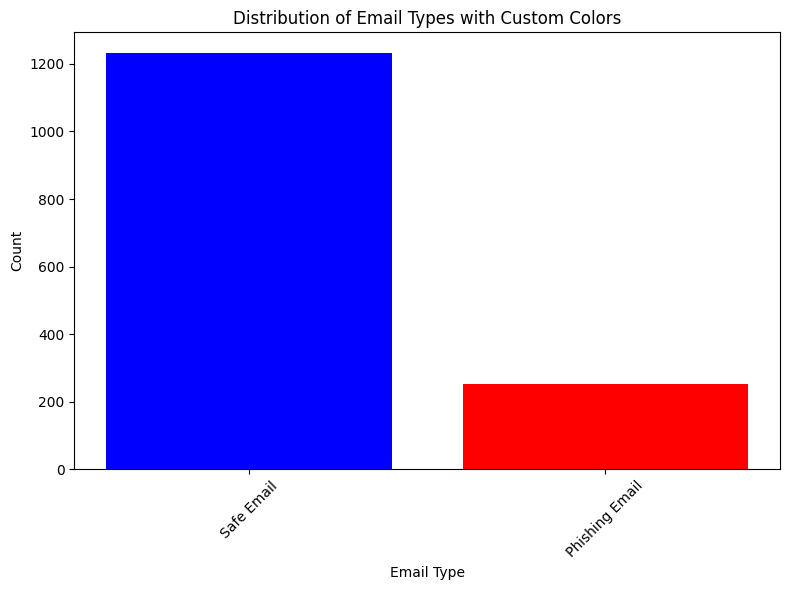

In [11]:
# Create the bar chart
# Create a list of unique email types
unique_email_types = email_type_counts.index.tolist()

# Define a custom color map 
color_map = {
    'Phishing Email': 'red',
    'Safe Email': 'blue',}

# Map the colors to each email type
colors = [color_map.get(email_type, 'gray') for email_type in unique_email_types]

# Create the bar chart with custom colors
plt.figure(figsize=(8, 6))
plt.bar(unique_email_types, email_type_counts, color=colors)
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.title('Distribution of Email Types with Custom Colors')
plt.xticks(rotation=45)

# Show the chart
plt.tight_layout()
plt.show()

In [12]:
# # We will use undersapling technique 
Safe_Email = df[df["email_type"]== "Safe Email"]
Phishing_Email = df[df["email_type"]== "Phishing Email"]
Safe_Email = Safe_Email.sample(Phishing_Email.shape[0])

In [13]:
# lets check the sahpe again 
Safe_Email.shape,Phishing_Email.shape

((252, 17), (252, 17))

In [14]:
# lest create a new Data with the balanced E-mail types
Data= pd.concat([Safe_Email, Phishing_Email], ignore_index = True)
Data.head()

,email_text,hostname,host_up,alternate_ip_count,ip_address,common_web_ports_open,open_ports_count,filtered_ports_count,open_ports,rdns_record,https_supported,services,host_found,interesting_url,asn_found,ip_found,email_type
0,"On Wed, Jul 31, 2002 at 06:57:50PM +0100, Bria...",,0,0,,0,0,0,,,0,,0,0,0,0,Safe Email
1,>It seems good Ol' Uncle Dave is once again tr...,www.oreillynet.com,0,0,34.169.83.167,0,0,0,"443, 8008, 80",167.83.169.34.bc.googleusercontent.com,0,"http, https",0,0,0,0,Safe Email
2,"URL: http://www.newsisfree.com/click/-0,861366...",www.newsisfree.com,1,1,172.67.205.86,1,5,994,"80, 8008, 8080, 8443, 443",,1,"http-proxy, http, https-alt, https",0,0,0,6,Safe Email
3,"URL: http://www.newsisfree.com/click/-1,839102...",www.newsisfree.com,1,1,172.67.205.86,1,5,994,"80, 8008, 8080, 8443, 443",,1,"http-proxy, http, https-alt, https",0,0,0,6,Safe Email
4,Hi all.\nDoes anyone know how to set up dual k...,,0,0,,0,0,0,,,0,,0,0,0,0,Safe Email


In [15]:
# # split the data into a metrix of features X and Dependent Variable y
X = Data["email_text"].values
y = Data["email_type"].values

Accuracy: 0.92
Precision: 1.00
Recall: 0.49
F1 Score: 0.66
Confusion Matrix:
[[373   0]
 [ 37  36]]


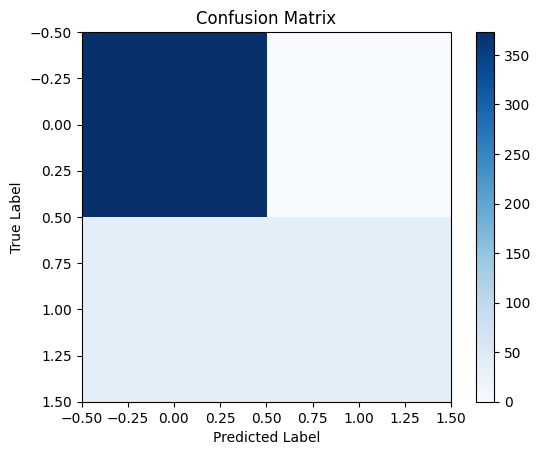

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from scipy.sparse import hstack
import matplotlib.pyplot as plt

# Replace labels and convert to integer
df['email_type'] = df['email_type'].replace({'Safe Email': 0, 'Phishing Email': 1}).astype(int)

# Define categorical and numerical features
categorical_features = ['hostname', 'rdns_record', 'services', 'ip_address', 'open_ports']
numerical_features = [
    'host_up', 'alternate_ip_count', 'common_web_ports_open',
    'open_ports_count', 'filtered_ports_count', 'https_supported',
    'host_found', 'interesting_url', 'asn_found', 'ip_found'
]

# Handle missing values
df[numerical_features] = df[numerical_features].fillna(0)
df[categorical_features] = df[categorical_features].fillna('unknown')

# Encode categorical features
onehot = OneHotEncoder(handle_unknown='ignore')
encoded_categorical = onehot.fit_transform(df[categorical_features])

# Scale numerical features
scaler = MinMaxScaler()
scaled_numerical = scaler.fit_transform(df[numerical_features])

# Combine categorical and numerical features
X_additional = hstack([encoded_categorical, scaled_numerical])

# Convert email text feature using TF-IDF
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(df['email_text'])

# Combine TF-IDF-transformed text and additional features
X_combined = hstack([X_text, X_additional])

# Define the target variable
Y = df['email_type']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, Y, test_size=0.3, random_state=1)

# Train the RandomForestClassifier
classifier = RandomForestClassifier(class_weight='balanced', n_estimators=10, random_state=1)
classifier.fit(X_train, y_train)

# Prediction
y_pred = classifier.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display results
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Plot Confusion Matrix (Optional)
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [16]:
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
# from scipy.sparse import hstack
# import matplotlib.pyplot as plt
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.pipeline import Pipeline

# # Replace labels and convert to integer
# df['email_type'] = df['email_type'].replace({'Safe Email': 0, 'Phishing Email': 1}).astype(int)

# # Define categorical and numerical features
# categorical_features = ['hostname', 'rdns_record', 'services', 'ip_address', 'open_ports']
# numerical_features = [
#     'host_up', 'alternate_ip_count', 'common_web_ports_open',
#     'open_ports_count', 'filtered_ports_count', 'https_supported',
#     'host_found', 'interesting_url', 'asn_found', 'ip_found'
# ]

# # Handle missing values
# df[numerical_features] = df[numerical_features].fillna(0)
# df[categorical_features] = df[categorical_features].fillna('unknown')

# # Encode categorical features
# onehot = OneHotEncoder(handle_unknown='ignore')
# encoded_categorical = onehot.fit_transform(df[categorical_features])

# # Scale numerical features
# scaler = MinMaxScaler()
# scaled_numerical = scaler.fit_transform(df[numerical_features])

# # Combine categorical and numerical features
# X_additional = hstack([encoded_categorical, scaled_numerical])

# # # Convert email text feature using TF-IDF
# # tfidf = TfidfVectorizer()
# # X_text = tfidf.fit_transform(df['email_text'])

# # Combine TF-IDF-transformed text and additional features
# X_combined = hstack([X_text, X_additional])

# # Define the target variable
# Y = df['email_type']

# # Split into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X_combined, Y, test_size=0.3, random_state=1)


# # define the Classifier
# classifier = Pipeline([("tfidf",TfidfVectorizer()),("classifier",RandomForestClassifier(class_weight='balanced',n_estimators=10))])

# # Trian Our model
# classifier.fit(X_train,y_train)

# # Prediction
# y_pred = classifier.predict(X_test)

# # Calculate evaluation metrics
# accuracy = accuracy_score(y_test, y_pred)
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)

# # Display results
# print(f"Accuracy: {accuracy:.2f}")
# print(f"Precision: {precision:.2f}")
# print(f"Recall: {recall:.2f}")
# print(f"F1 Score: {f1:.2f}")

# # Confusion Matrix
# conf_matrix = confusion_matrix(y_test, y_pred)
# print("Confusion Matrix:")
# print(conf_matrix)

# # Plot Confusion Matrix (Optional)
# plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
# plt.colorbar()
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.show()

C:\Users\Rana Shafi\AppData\Local\Temp\ipykernel_21948\844849363.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['email_type'] = df['email_type'].replace({'Safe Email': 0, 'Phishing Email': 1}).astype(int)


AttributeError: 'csr_matrix' object has no attribute 'lower'

In [18]:
# Importing classification_report,accuracy_score,confusion_matrix
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,recall_score,precision_score

In [19]:
#accuracy_score
accuracy = accuracy_score(y_test,y_pred)

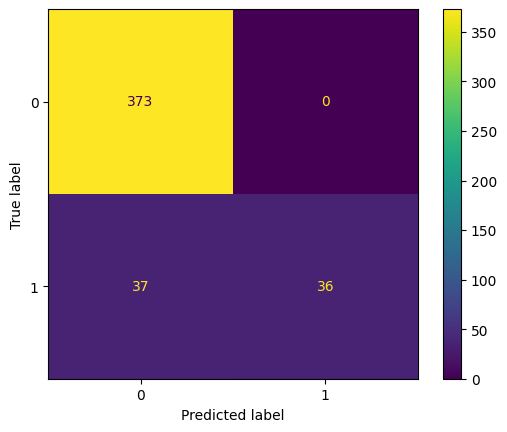

In [20]:
#confusion_matrix
conf = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(confusion_matrix=conf).plot()

In [22]:
precision = precision_score(y_test, y_pred,pos_label=1)
recall = recall_score(y_test, y_pred,pos_label=1)

In [23]:
# record accuracy in file
with open("english_osint_RF_result.txt", "a") as file:
    file.write(f"\n  Model Accuracy: {accuracy:.2f}\n Recall:{recall:.2f}\n Precision:{precision:.2f} \n Confusion matrix: \n{conf}")